## Calculating Energies

When we do long Caldeira Leggett simulations, it can become a lot of data to store if we want to keep track of the full wavefunction. To overcome this we can just keep track of specific parameters, such as the energy or location of the wavefunction.


Text(0.5, 1.0, 'Energy of the state')

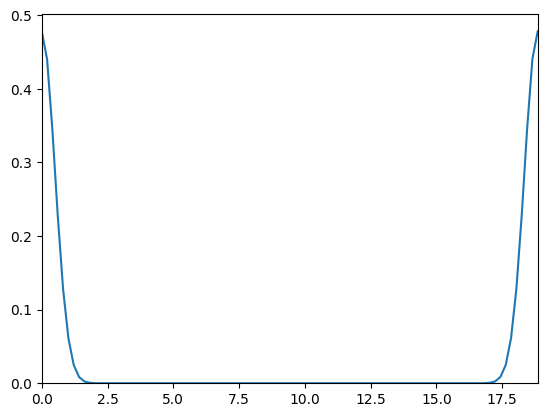

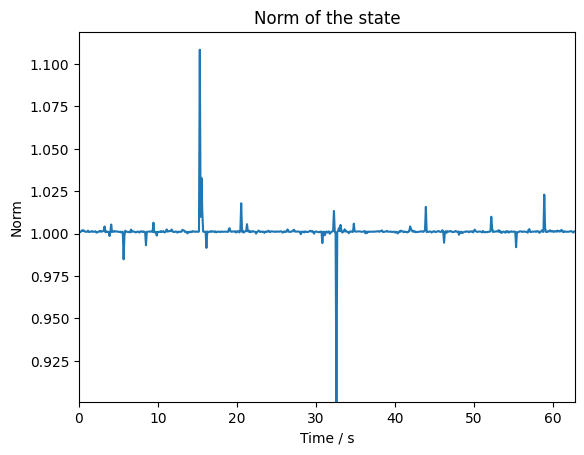

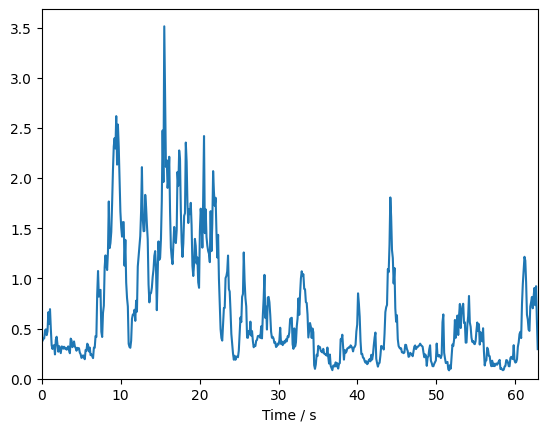

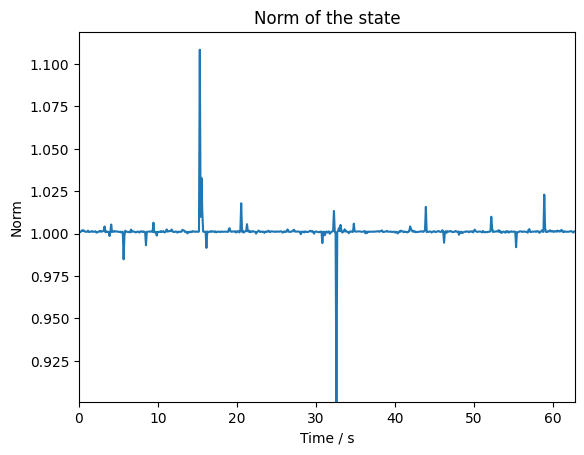

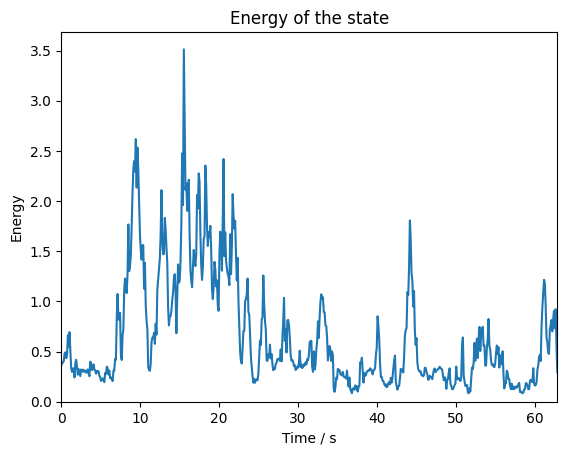

In [2]:
from pathlib import Path

import numpy as np
from scipy.constants import Boltzmann  # type: ignore stubs
from slate_core import Array, Basis, FundamentalBasis, TupleBasis
from slate_core.metadata import (
    Domain,
    spaced_volume_metadata_from_stacked_delta_x,
)
from slate_core.plot import array_against_axes_1d, array_against_basis
from slate_core.util import cached

from slate_quantum import operator, state
from slate_quantum.dynamics import (
    LangevinParameters,
    caldeira_leggett,
)
from slate_quantum.metadata import EigenvalueMetadata, SpacedTimeMetadata

metadata = spaced_volume_metadata_from_stacked_delta_x((np.array([2 * np.pi]),), (31,))

potential_single = operator.build.cos_potential(metadata, 2)
potential = operator.build.repeat_potential(potential_single, (3,))
potential_metadata = potential.basis.inner.outer_recast.metadata()


initial_state = state.build_coherent(potential_metadata, (0,), (0,), sigma_0=(0.5,))


parameters = LangevinParameters(mass=1, lambda_=0.5, temperature=8 / Boltzmann, hbar=1)

fig, ax, line = array_against_axes_1d(initial_state)


@cached(Path("data/caldeira_leggett_energies.npz"))
def _simulate() -> tuple[
    Array[
        TupleBasis[tuple[FundamentalBasis, Basis[SpacedTimeMetadata]], None],
        np.dtype[np.floating],
    ],
    Array[
        TupleBasis[tuple[FundamentalBasis, Basis[SpacedTimeMetadata]], None],
        np.dtype[np.floating],
    ],
]:
    times = FundamentalBasis(SpacedTimeMetadata(600, domain=Domain(delta=20 * np.pi)))

    return caldeira_leggett.solve_periodic_energies(
        initial_state,
        times,
        parameters,
        potential,
        method="Platen",
        target_delta=1e-3,
    )


energies, norms = _simulate()


fig, ax, line = array_against_basis(norms[0, :])
ax.set_xlabel("Time / s")
ax.set_ylabel("Norm")
ax.set_title("Norm of the state")

fig, ax, line = array_against_basis(energies[0, :], measure="abs")
ax.set_xlabel("Time / s")


fig, ax, line = array_against_basis(norms[0, :])
ax.set_xlabel("Time / s")
ax.set_ylabel("Norm")
ax.set_title("Norm of the state")

fig, ax, line = array_against_basis(energies[0, :], measure="abs")
ax.set_xlabel("Time / s")
ax.set_ylabel("Energy")
ax.set_title("Energy of the state")


In [ ]:
from pathlib import Path
from typing import Any

import numpy as np
import scipy.optimize  # type: ignore aa
from scipy.constants import Boltzmann  # type: ignore stubs
from slate_core import array
from slate_core.plot import array_against_basis
from slate_core.util import cached

from slate_quantum import operator, state
from slate_quantum.operator import operator_basis


@cached(Path("data/caldeira_leggett_occupations.npz"))
def _simulate_eigenstate_occupations() -> Array[
    FundamentalBasis[EigenvalueMetadata], np.dtype[np.floating]
]:
    times = FundamentalBasis(SpacedTimeMetadata(600, domain=Domain(delta=60 * np.pi)))

    simulated_states = caldeira_leggett.solve_periodic(
        initial_state,
        times,
        parameters,
        potential,
        method="Rouchon",
        target_delta=2e-4,
    )
    # Note this conversion truncates some terms in the hamiltonian
    # but the simulation also uses a truncated hamiltonian so
    # this find the eigenstates in a way which is self consistent with the simulation.
    hamiltonian = operator.build.kinetic_hamiltonian(
        potential.with_basis(operator_basis(simulated_states.basis.inner.children[1])),  # type: ignore aa
        parameters.mass,
        hbar=parameters.hbar,
    )
    diagonal = operator.linalg.into_diagonal_hermitian(hamiltonian)  # type: ignore aa
    eigenstate_basis = diagonal.basis.inner.inner.children[0]  # type: ignore aa
    simulated_states = simulated_states.with_state_basis(eigenstate_basis)
    occupations = state.get_all_occupations(simulated_states)
    overlaps = array.flatten(array.average(occupations, axis=0)).as_array()  # type: ignore aa
    return Array(
        FundamentalBasis(EigenvalueMetadata(diagonal.raw_data)),
        overlaps.astype(np.float64),  # type: ignore aa
    )


occupations = _simulate_eigenstate_occupations.call_cached()

fig, ax, line = array_against_basis(occupations, measure="real", scale="log")
line.set_label("Simulated")


ax.set_xlabel("Energy / J")
ax.set_ylabel("Occupation")
ax.set_title("Eigenstate Occupations")

occupations_data = occupations.as_array()
energy_points = np.real(occupations.basis.metadata().values)


def _boltzmann_fit(
    energy: np.ndarray[Any, np.dtype[np.floating]], beta: float, b: float
) -> np.ndarray:
    return b - beta * energy


def _fit_to_boltzmann(
    energies: np.ndarray[Any, np.dtype[np.floating]],
    occupations: np.ndarray[Any, np.dtype[np.floating]],
) -> tuple[float, float]:

    min_occupation = 10**-9

    optimal_parameters, _ = scipy.optimize.curve_fit(  # type: ignore scipy
        _boltzmann_fit,
        energies[occupations > min_occupation],
        np.log(occupations[occupations > min_occupation]),
    )
    return optimal_parameters  # type: ignore scipy


beta_fit, b_fit = _fit_to_boltzmann(energy_points, occupations_data)
boltzmann_fit_values = _boltzmann_fit(energy_points, beta_fit, b_fit)
(line,) = ax.plot(energy_points, np.exp(boltzmann_fit_values))
line.set_label(f"Boltzmann Fit (KbT = {1 / beta_fit:.2f} J)")

boltzmann_fit_values = _boltzmann_fit(energy_points, 1 / parameters.kbt, b_fit)
(line,) = ax.plot(energy_points, np.exp(boltzmann_fit_values))
line.set_label(f"From Parameters (KbT = {parameters.kbt:.2f} J)")
ax.legend()
ax.set_title("Eigenstate Occupations with Boltzmann Fit")
ax.set_ylim(bottom=1e-6)
ax.set_xlim(None, 2.5 * parameters.kbt)

line.set_label("Boltzmann Fit")

NameError: name 'FundamentalBasis' is not defined